<a href="https://colab.research.google.com/github/alimor37/WAAM_Weld_ML/blob/main/1_Data_Relationship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing cleaned data to see if it is all numeric or not!**

In [1]:

import pandas as pd

# Load dataset
github_url = "https://raw.githubusercontent.com/alimor37/WAAM_Weld_ML/main/Cleaned_data.xlsx"
df = pd.read_excel(github_url)

# Basic dataset information
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

# Numerical descriptive statistics
print("\nDescriptive statistics:")
print(df.describe(include="all").T.to_string())

# Missing values
print("\nMissing values:")
print(df.isna().sum().to_string())

# Save results
df.describe(include="all").T.to_excel(
    "EDA_Descriptive_Statistics.xlsx"
)

print("\nEDA summary saved successfully!")


Dataset shape: (30, 37)

Column names:
['Weld_Method', 'Weld_ID', 'Base_Material', 'Consumable', 'No_of_Beads', 't85_s', 'C', 'Si', 'Mn', 'P', 'S', 'Cr', 'Ni', 'Mo', 'V', 'Nb', 'Cu', 'Al', 'Ti', 'B', 'O', 'N', 'CE_IIW', 'Pcm', 'Cen', 'CET', 'Dilution_Ni_pct', 'Rp0.2_Mpa', 'Rm_Mpa', 'A5_pct', 'Cv -80ºC (J)', 'Cv -60ºC (J)', 'Cv -40ºC (J)', 'Cv -20ºC (J)', 'Cv +20ºC (J)', 'Transverse_Rm_Mpa', 'Fracture_Location']

Descriptive statistics:
                  count unique              top freq         mean        std       min       25%       50%       75%       max
Weld_Method          30      5              MAG   16          NaN        NaN       NaN       NaN       NaN       NaN       NaN
Weld_ID              30     21                ?   10          NaN        NaN       NaN       NaN       NaN       NaN       NaN
Base_Material        30      2       Weldox 700   16          NaN        NaN       NaN       NaN       NaN       NaN       NaN
Consumable           30      8  OK Aristorod 79    7

**Make the cleaned data to a fully Numeric file!**

In [5]:

import pandas as pd
import numpy as np

# ==========================================
# STEP 1: Load original Excel file
# ==========================================

# Load dataset
github_url = "https://raw.githubusercontent.com/alimor37/WAAM_Weld_ML/main/Cleaned_data.xlsx"
df = pd.read_excel(github_url)

print("Original dataset shape:", df.shape)


# ==========================================
# STEP 2: Define numerical columns
# ==========================================

numeric_cols = [
    "No_of_Beads", "t85_s",
    "C", "Si", "Mn", "P", "S", "Cr",
    "Ni", "Mo", "V", "Nb", "Cu",
    "Al", "Ti", "B", "O", "N",
    "CE_IIW", "Pcm", "Cen", "CET",
    "Dilution_Ni_pct",
    "Rp0.2_Mpa", "Rm_Mpa", "A5_pct",
    "Cv -80ºC (J)",
    "Cv -60ºC (J)",
    "Cv -40ºC (J)",
    "Cv -20ºC (J)",
    "Cv +20ºC (J)",
    "Transverse_Rm_Mpa"
]


# ==========================================
# STEP 3: Convert text values to NaN
# ==========================================

# Keep an audit of the original invalid values
invalid_records = []

for col in numeric_cols:

    original = df[col].copy()

    # Convert values to strings for cleaning
    cleaned = original.astype("string").str.strip()

    # Replace missing-value markers
    cleaned = cleaned.replace(
        ["-", "?", "", "nan", "None"],
        pd.NA
    )

    # Convert to numeric
    converted = pd.to_numeric(
        cleaned,
        errors="coerce"
    )

    # Find non-empty values that could not
    # be converted to numbers
    invalid = original.notna() & converted.isna()

    if invalid.any():

        print(f"\nColumn: {col}")
        print("Invalid values found:")

        for idx in df.index[invalid]:

            value = original.loc[idx]

            print(
                f"Excel row {idx + 2}: {value}"
            )

            invalid_records.append({
                "Excel_Row": idx + 2,
                "Weld_ID": df.loc[idx, "Weld_ID"],
                "Column": col,
                "Original_Value": str(value)
            })

    # Replace column with numeric values
    df[col] = converted


# ==========================================
# STEP 4: Data quality summary
# ==========================================

summary = pd.DataFrame({
    "Valid_N": df[numeric_cols].notna().sum(),
    "Missing_N": df[numeric_cols].isna().sum(),
    "Missing_pct": (
        df[numeric_cols].isna().mean() * 100
    ).round(2)
})

print("\n" + "=" * 55)
print("DATA CLEANING SUMMARY")
print("=" * 55)

print(summary.to_string())


# ==========================================
# STEP 5: Check number of rows
# ==========================================

print("\n" + "=" * 55)
print("FINAL DATASET CHECK")
print("=" * 55)

print("Total rows:", len(df))
print("Total columns:", len(df.columns))

print(
    "Valid Rp0.2 samples:",
    df["Rp0.2_Mpa"].notna().sum()
)

print(
    "Valid Rm samples:",
    df["Rm_Mpa"].notna().sum()
)

print(
    "Valid Charpy -40C samples:",
    df["Cv -40ºC (J)"].notna().sum()
)


# ==========================================
# STEP 6: Save cleaned data and reports
# ==========================================

df.to_excel(
    "Cleaned_data_numeric.xlsx",
    index=False
)

summary.to_excel(
    "Data_Quality_Summary.xlsx"
)

invalid_df = pd.DataFrame(
    invalid_records,
    columns=[
        "Excel_Row",
        "Weld_ID",
        "Column",
        "Original_Value"
    ]
)

invalid_df.to_excel(
    "Invalid_Values_Report.xlsx",
    index=False
)

print("\nAll files saved successfully!")


Original dataset shape: (30, 37)

Column: O
Invalid values found:
Excel row 10: -
Excel row 11: -
Excel row 12: -
Excel row 13: -
Excel row 14: -
Excel row 15: -

Column: Rp0.2_Mpa
Invalid values found:
Excel row 14: specimen broke at threads
Excel row 25: Not enough defect free material

Column: Cv -80ºC (J)
Invalid values found:
Excel row 15: -
Excel row 23: -
Excel row 25: -

Column: Cv +20ºC (J)
Invalid values found:
Excel row 23: -
Excel row 25: -

DATA CLEANING SUMMARY
                   Valid_N  Missing_N  Missing_pct
No_of_Beads             30          0         0.00
t85_s                   30          0         0.00
C                       30          0         0.00
Si                      30          0         0.00
Mn                      30          0         0.00
P                       30          0         0.00
S                       30          0         0.00
Cr                      30          0         0.00
Ni                      30          0         0.00
Mo        

**To find out what outliers do we have!**

Dataset shape: (30, 37)

MECHANICAL PROPERTY STATISTICS
              count         mean         std    min     25%     50%      75%     max  Missing_N
Rp0.2_Mpa      28.0   872.428571  109.415088  664.0  806.25   885.5   938.50  1057.0          2
Rm_Mpa         28.0  1017.464286   78.268996  849.0  964.50  1042.5  1073.75  1152.0          2
Cv -40ºC (J)   30.0    52.533333   18.622814   18.0   35.00    56.5    69.00    82.0          0


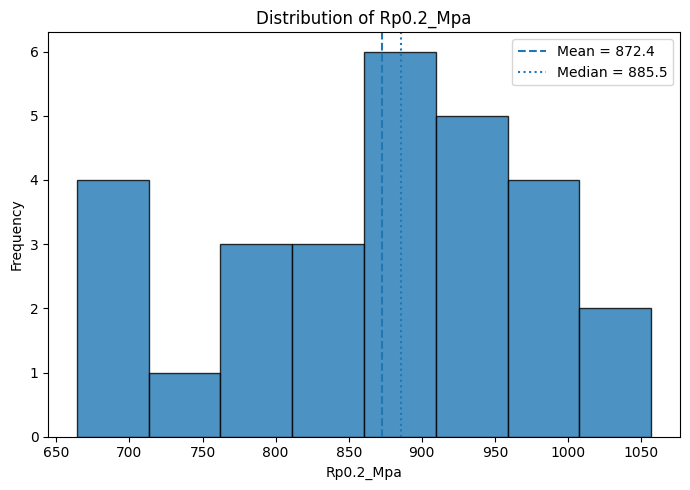

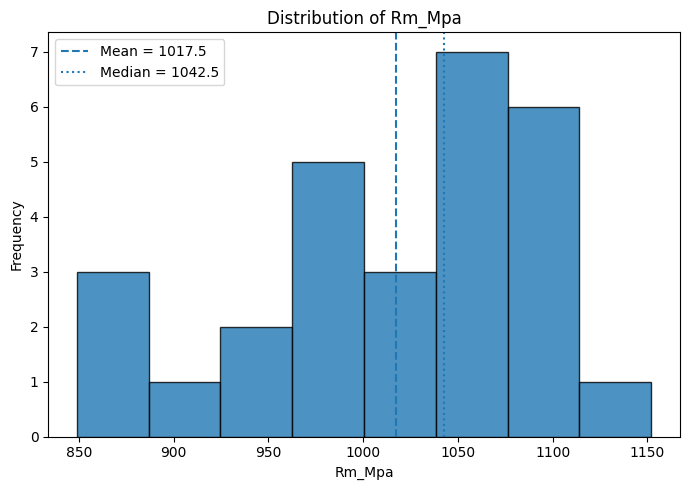

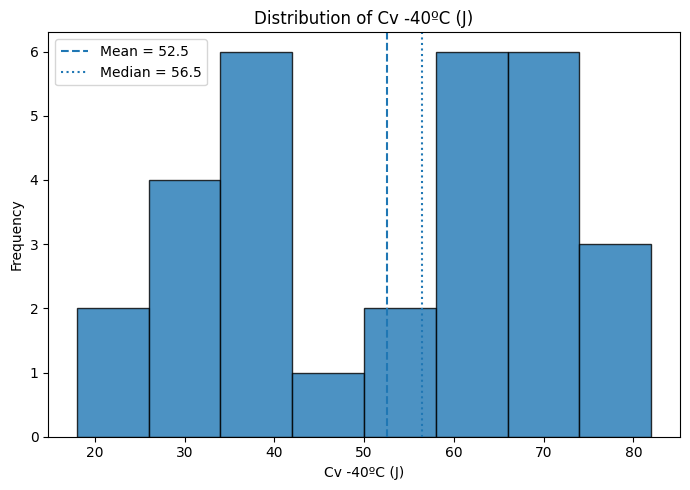

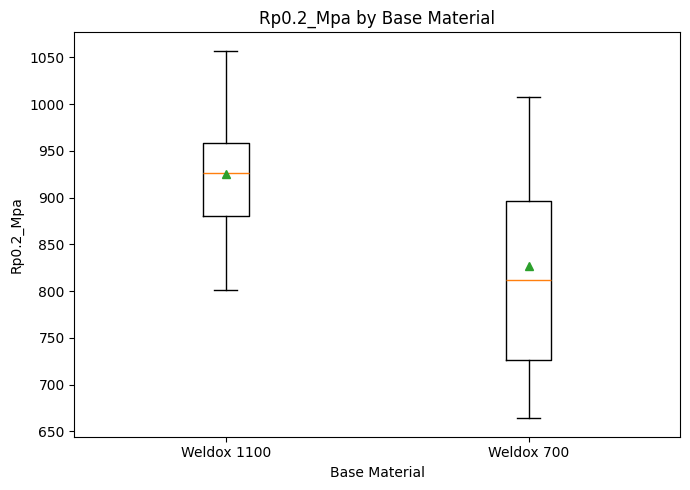

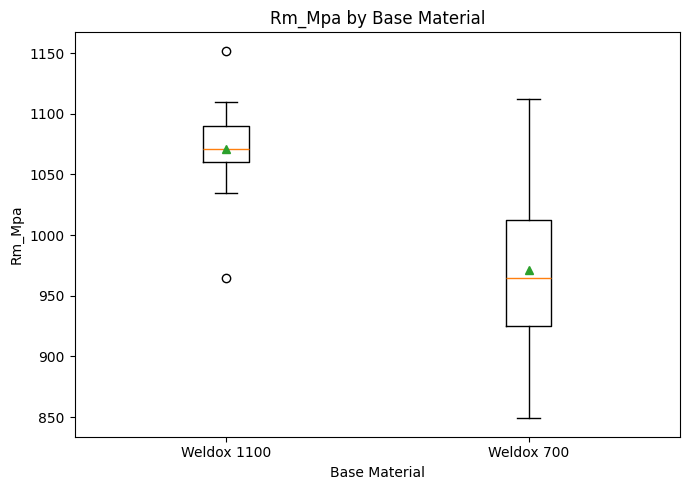

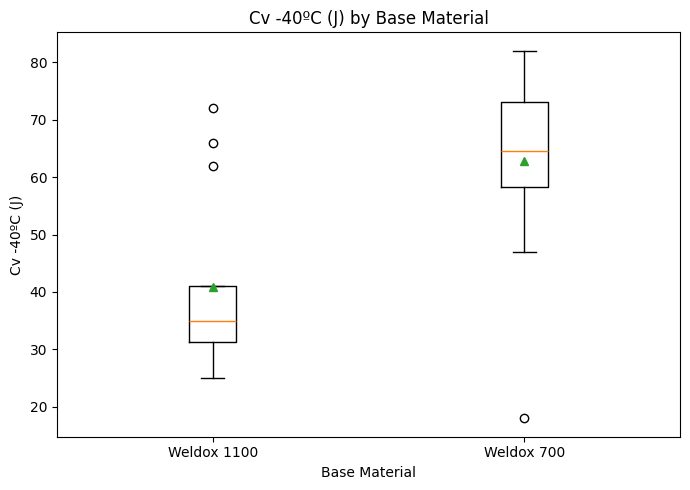


Target: Rp0.2_Mpa
Lower IQR bound: 607.88
Upper IQR bound: 1136.88
Possible outliers: 0

Target: Rm_Mpa
Lower IQR bound: 800.62
Upper IQR bound: 1237.62
Possible outliers: 0

Target: Cv -40ºC (J)
Lower IQR bound: -16.00
Upper IQR bound: 120.00
Possible outliers: 0

Analysis completed successfully!
No observations were removed.


In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# STEP 1: Load cleaned dataset from GitHub
# ==========================================

github_url = (
    "https://raw.githubusercontent.com/"
    "alimor37/WAAM_Weld_ML/main/"
    "Cleaned_data_numeric.xlsx"
)

df = pd.read_excel(github_url)

print("Dataset shape:", df.shape)

# ==========================================
# STEP 2: Select mechanical properties
# ==========================================

targets = [
    "Rp0.2_Mpa",
    "Rm_Mpa",
    "Cv -40ºC (J)"
]

# ==========================================
# STEP 3: Descriptive statistics
# ==========================================

stats = df[targets].describe().T

stats["Missing_N"] = df[targets].isna().sum()

print("\nMECHANICAL PROPERTY STATISTICS")
print("=" * 60)
print(stats.to_string())

# ==========================================
# STEP 4: Histograms
# ==========================================

for col in targets:

    values = df[col].dropna()

    plt.figure(figsize=(7, 5))

    plt.hist(
        values,
        bins=8,
        edgecolor="black",
        alpha=0.8
    )

    plt.axvline(
        values.mean(),
        linestyle="--",
        label=f"Mean = {values.mean():.1f}"
    )

    plt.axvline(
        values.median(),
        linestyle=":",
        label=f"Median = {values.median():.1f}"
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==========================================
# STEP 5: Boxplots by base material
# ==========================================

for col in targets:

    groups = []
    labels = []

    for material, group in df.groupby("Base_Material"):

        values = group[col].dropna()

        if len(values) > 0:
            groups.append(values)
            labels.append(material)

    plt.figure(figsize=(7, 5))

    plt.boxplot(
        groups,
        tick_labels=labels,
        showmeans=True
    )

    plt.title(f"{col} by Base Material")
    plt.xlabel("Base Material")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# ==========================================
# STEP 6: Identify possible outliers (IQR)
# ==========================================

outlier_records = []

for col in targets:

    values = df[col].dropna()

    Q1 = values.quantile(0.25)
    Q3 = values.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (
        df[col].notna()
        & ((df[col] < lower) | (df[col] > upper))
    )

    print(f"\nTarget: {col}")
    print(f"Lower IQR bound: {lower:.2f}")
    print(f"Upper IQR bound: {upper:.2f}")
    print(f"Possible outliers: {mask.sum()}")

    for idx, row in df.loc[mask].iterrows():

        outlier_records.append({
            "Excel_Row": idx + 2,
            "Weld_ID": row["Weld_ID"],
            "Base_Material": row["Base_Material"],
            "Weld_Method": row["Weld_Method"],
            "Target": col,
            "Value": row[col]
        })

# ==========================================
# STEP 7: Save results
# ==========================================

outlier_df = pd.DataFrame(
    outlier_records,
    columns=[
        "Excel_Row",
        "Weld_ID",
        "Base_Material",
        "Weld_Method",
        "Target",
        "Value"
    ]
)

stats.to_excel(
    "EDA_Mechanical_Statistics.xlsx"
)

outlier_df.to_excel(
    "EDA_Possible_Outliers.xlsx",
    index=False
)

print("\nAnalysis completed successfully!")
print("No observations were removed.")


**Correlation & Multicollinearity Analysis in chemical comporsition**


FEATURE–TARGET CORRELATIONS
                 Rp0.2_Mpa  Rm_Mpa  Cv -40ºC (J)
No_of_Beads          0.597   0.238         0.248
t85_s               -0.370  -0.310         0.038
C                   -0.154   0.154        -0.323
Si                  -0.291  -0.067        -0.262
Mn                   0.123   0.011        -0.029
P                   -0.364  -0.523         0.394
S                   -0.485  -0.554         0.281
Cr                   0.182   0.116         0.224
Ni                   0.542   0.243         0.323
Mo                   0.602   0.504        -0.119
V                    0.330   0.554        -0.556
Nb                   0.773   0.806        -0.300
Cu                  -0.275  -0.033        -0.504
Al                  -0.032   0.250        -0.556
Ti                   0.471   0.631        -0.392
B                    0.061   0.222        -0.202
O                   -0.230  -0.336         0.139
N                    0.257   0.301        -0.107
CE_IIW               0.584   0.370      

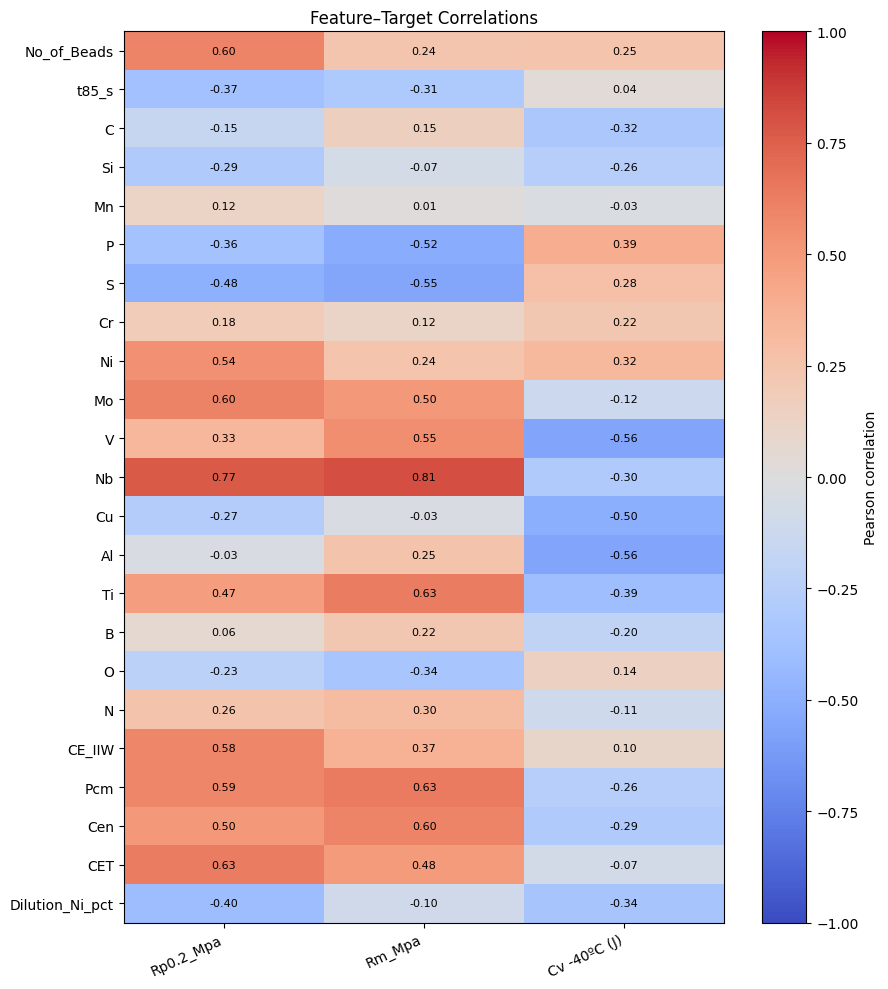


Correlation analysis completed!
No data were modified or removed.


In [8]:

import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# STEP 1: Load cleaned dataset
# ==========================================

github_url = (
    "https://raw.githubusercontent.com/"
    "alimor37/WAAM_Weld_ML/main/"
    "Cleaned_data_numeric.xlsx"
)

df = pd.read_excel(github_url)

# ==========================================
# STEP 2: Define input features
# ==========================================

features = [
    "No_of_Beads", "t85_s",
    "C", "Si", "Mn", "P", "S",
    "Cr", "Ni", "Mo", "V", "Nb",
    "Cu", "Al", "Ti", "B", "O", "N",
    "CE_IIW", "Pcm", "Cen", "CET",
    "Dilution_Ni_pct"
]

targets = [
    "Rp0.2_Mpa",
    "Rm_Mpa",
    "Cv -40ºC (J)"
]

# ==========================================
# STEP 3: Calculate Pearson correlations
# ==========================================

corr = pd.DataFrame(index=features)

for target in targets:

    corr[target] = df[features].corrwith(
        df[target],
        method="pearson"
    )

print("\nFEATURE–TARGET CORRELATIONS")
print("=" * 65)
print(corr.round(3).to_string())

# ==========================================
# STEP 4: Plot correlation heatmap
# ==========================================

fig, ax = plt.subplots(figsize=(9, 10))

im = ax.imshow(
    corr.values,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

ax.set_xticks(range(len(targets)))
ax.set_xticklabels(targets, rotation=25, ha="right")

ax.set_yticks(range(len(features)))
ax.set_yticklabels(features)

for i in range(len(features)):
    for j in range(len(targets)):
        value = corr.iloc[i, j]
        ax.text(
            j, i, f"{value:.2f}",
            ha="center", va="center",
            fontsize=8
        )

fig.colorbar(im, ax=ax, label="Pearson correlation")
ax.set_title("Feature–Target Correlations")

plt.tight_layout()
plt.show()

# ==========================================
# STEP 5: Save results
# ==========================================

corr.to_excel(
    "EDA_Feature_Target_Correlations.xlsx"
)

fig.savefig(
    "EDA_Feature_Target_Correlations.png",
    dpi=300,
    bbox_inches="tight"
)

print("\nCorrelation analysis completed!")
print("No data were modified or removed.")


**Lets do a feature-feature correlation!**

HIGHLY CORRELATED FEATURE PAIRS
  Feature_1       Feature_2  Pearson_r    Abs_r
     CE_IIW             CET      0.941 0.941226
         Ni          CE_IIW      0.912 0.911708
        Pcm             Cen      0.909 0.908828
         Ni Dilution_Ni_pct     -0.870 0.870302
          P              Ti     -0.862 0.861570
No_of_Beads              Ni      0.777 0.777171
         Si              Cu      0.774 0.773522
        Pcm             CET      0.768 0.767628
     CE_IIW Dilution_Ni_pct     -0.763 0.763172
         Ni             CET      0.758 0.758442


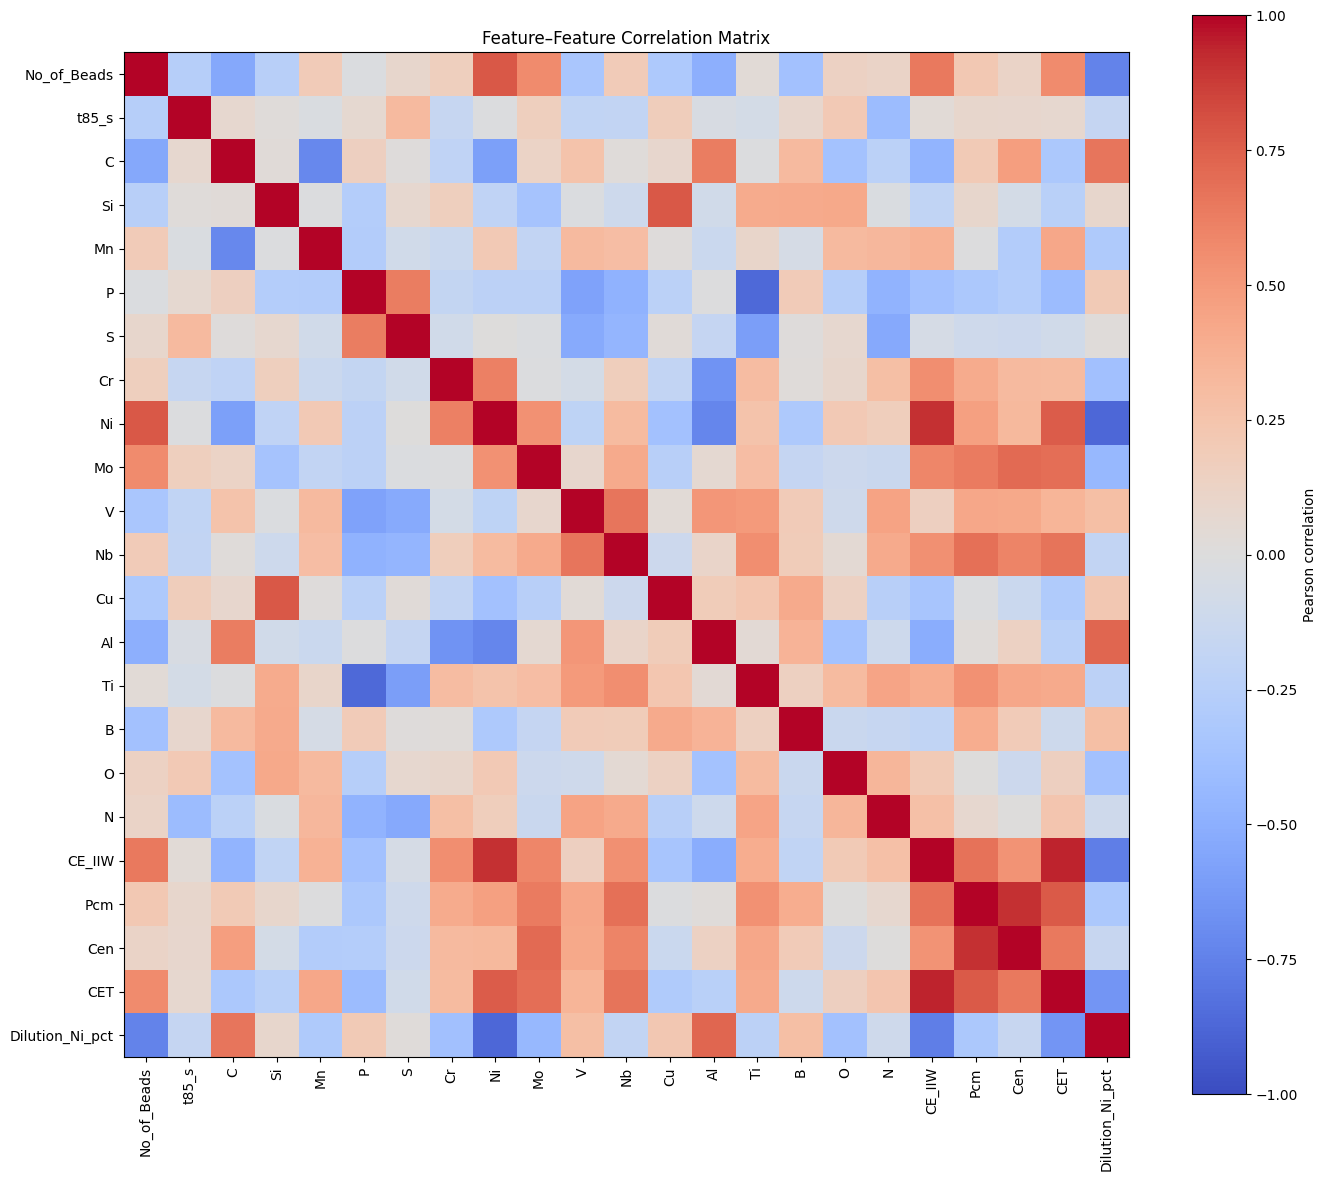


Analysis completed!
No features or samples were removed.


In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load cleaned data
github_url = (
    "https://raw.githubusercontent.com/"
    "alimor37/WAAM_Weld_ML/main/"
    "Cleaned_data_numeric.xlsx"
)

df = pd.read_excel(github_url)

# Define input features
features = [
    "No_of_Beads", "t85_s",
    "C", "Si", "Mn", "P", "S",
    "Cr", "Ni", "Mo", "V", "Nb",
    "Cu", "Al", "Ti", "B", "O", "N",
    "CE_IIW", "Pcm", "Cen", "CET",
    "Dilution_Ni_pct"
]

# Pearson correlation matrix
corr_matrix = df[features].corr(method="pearson")

# Find highly correlated feature pairs
threshold = 0.75

strong_pairs = []

for i in range(len(features)):
    for j in range(i + 1, len(features)):

        r = corr_matrix.iloc[i, j]

        if pd.notna(r) and abs(r) >= threshold:
            strong_pairs.append({
                "Feature_1": features[i],
                "Feature_2": features[j],
                "Pearson_r": round(r, 3),
                "Abs_r": abs(r)
            })

strong_df = pd.DataFrame(
    strong_pairs,
    columns=[
        "Feature_1", "Feature_2",
        "Pearson_r", "Abs_r"
    ]
)

strong_df = strong_df.sort_values(
    "Abs_r", ascending=False
)

print("HIGHLY CORRELATED FEATURE PAIRS")
print("=" * 65)
print(strong_df.to_string(index=False))

# Heatmap
fig, ax = plt.subplots(figsize=(14, 12))

im = ax.imshow(
    corr_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(features)))
ax.set_xticklabels(features, rotation=90)

ax.set_yticks(range(len(features)))
ax.set_yticklabels(features)

fig.colorbar(im, ax=ax, label="Pearson correlation")

ax.set_title("Feature–Feature Correlation Matrix")

plt.tight_layout()
plt.show()

# Save results
corr_matrix.to_excel(
    "EDA_Feature_Feature_Correlation.xlsx"
)

strong_df.drop(columns="Abs_r").to_excel(
    "EDA_Strong_Correlations.xlsx",
    index=False
)

fig.savefig(
    "EDA_Feature_Feature_Correlation.png",
    dpi=300,
    bbox_inches="tight"
)

print("\nAnalysis completed!")
print("No features or samples were removed.")
